# IBM HR Attrition — Full ML + NLP/LLM Pipeline

This notebook implements the complete pipeline shown in the flowchart:

1. Load raw IBM HR Attrition dataset (1470 x 35)
2. Preprocessing: cleaning, outliers, correlation/VIF, skew correction, encoding, scaling
3. Stratified 60/20/20 train/validation/test split
4. SMOTE-based class-imbalance handling (inside pipeline, train folds only)
5. **Classical ML branch**: Decision Tree, SVM, Logistic Regression, Random Forest, Gradient Boosting
   (baseline → GridSearchCV tuning → Stacking → Blending)
6. **NLP/LLM branch**: row → text serialization → DistilBERT, BERT (fine-tuned NLP classifiers),
   Flan-T5, TinyLlama (prompted LLM classifiers)
7. Validation-set threshold selection + locked-threshold TEST evaluation (both branches)
8. Overall best-model selection by test F1 across both branches
9. Diagnostics for the best model (normalized confusion matrix, loss/accuracy curves)
10. Data augmentation comparison (SMOTE family + text augmentation)
11. Explainable AI (SHAP + LIME)
12. Ablation study (retrain-based, on the best model)

**Before running:** In Colab go to `Runtime > Change runtime type > T4 GPU` (the NLP/LLM branch
needs a GPU; the classical branch runs fine on CPU). Runtime for the full notebook top-to-bottom
is roughly 30–60+ minutes on a free Colab GPU, depending on queueing.

**Dataset:** This notebook expects the public *IBM HR Analytics Employee Attrition & Performance*
dataset (`WA_Fn-UseC_-HR-Employee-Attrition.csv`, 1470 rows x 35 columns), available on Kaggle at
`kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset`. Download it once and either
upload it when prompted below, or drop it in Colab's file browser at
`/content/WA_Fn-UseC_-HR-Employee-Attrition.csv` before running the data-loading cell.


In [1]:
# ============================================================
# 0. INSTALL DEPENDENCIES
# ============================================================
!pip -q install -U imbalanced-learn shap lime statsmodels evaluate accelerate sentencepiece
!pip -q install -U "transformers>=4.41.0" "datasets>=2.19.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.0 MB/s eta 0:00:00


In [2]:
# ============================================================
# 1. IMPORTS & GLOBAL CONFIG
# ============================================================
import os, io, json, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

from statsmodels.stats.outliers_influence import variance_inflation_factor

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM, AutoModelForCausalLM,
    Trainer, TrainingArguments
)

import shap
from lime.lime_tabular import LimeTabularExplainer
from lime.lime_text import LimeTextExplainer

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


## 1. Load the raw dataset (1470 x 35)

In [3]:
# ============================================================
# DATA LOADING
# ============================================================
DATA_PATH = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("Upload WA_Fn-UseC_-HR-Employee-Attrition.csv")
        print("(download from kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f"Place {DATA_PATH} in the working directory, or run this in Colab to be prompted to upload it."
        )

df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()


Upload WA_Fn-UseC_-HR-Employee-Attrition.csv
(download from kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)


Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv
Raw shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Preprocessing
Cleaning (drop constant/ID columns), outlier capping (IQR), correlation + VIF-based redundancy
removal, skew correction (log1p), then encoding/scaling is deferred to a `ColumnTransformer`
fitted **only on the training split** (see Section 4) so no information leaks from val/test.

In [4]:
# ============================================================
# 2. PREPROCESSING
# ============================================================
df = df_raw.copy()

# --- Cleaning: drop constant / identifier columns ---
drop_cols = [c for c in ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"] if c in df.columns]
df = df.drop(columns=drop_cols)
print("Dropped constant/ID columns:", drop_cols)

# --- Target encoding ---
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "Attrition"]
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# --- Outlier capping (IQR method) ---
def cap_outliers_iqr(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return series.clip(q1 - k * iqr, q3 + k * iqr)

for c in num_cols:
    df[c] = cap_outliers_iqr(df[c])

# --- Skew correction (log1p on strongly right-skewed non-negative columns) ---
skewed = df[num_cols].skew().sort_values(ascending=False)
skew_cols = [c for c in skewed[skewed.abs() > 1].index if (df[c] >= 0).all()]
for c in skew_cols:
    df[c] = np.log1p(df[c])
print("Skew-corrected columns:", skew_cols)

# --- Correlation-based redundancy removal (|corr| > 0.9) ---
corr_matrix = df[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
df = df.drop(columns=high_corr_drop)
num_cols = [c for c in num_cols if c not in high_corr_drop]
print("Dropped for high pairwise correlation (>0.9):", high_corr_drop)

# --- Iterative VIF-based redundancy removal (VIF > 10) ---
def compute_vif(frame, cols):
    X_ = frame[cols].assign(_const=1.0)
    return pd.Series(
        [variance_inflation_factor(X_.values, i) for i in range(len(cols))],
        index=cols
    ).sort_values(ascending=False)

vif_dropped = []
work_cols = num_cols.copy()
while len(work_cols) > 5:
    vifs = compute_vif(df, work_cols)
    if vifs.max() > 10:
        worst = vifs.idxmax()
        vif_dropped.append(worst)
        work_cols.remove(worst)
    else:
        break
print("Iteratively dropped for high VIF (>10):", vif_dropped)
df = df.drop(columns=vif_dropped)
num_cols = [c for c in num_cols if c not in vif_dropped]

print("\nFinal numeric columns:", num_cols)
print("Final categorical columns:", cat_cols)
print("Final dataframe shape:", df.shape)

X = df.drop(columns=["Attrition"])
y = df["Attrition"]


Dropped constant/ID columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Skew-corrected columns: ['YearsSinceLastPromotion', 'MonthlyIncome', 'JobLevel']
Dropped for high pairwise correlation (>0.9): ['MonthlyIncome']
Iteratively dropped for high VIF (>10): []

Final numeric columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Final categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Final dataframe shape: (1470, 30)


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stat

## 3. Stratified 60/20/20 split (Train / Validation / Test)

In [5]:
# ============================================================
# 3. STRATIFIED 60/20/20 SPLIT
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Attrition rate  | train: %.3f  val: %.3f  test: %.3f" %
      (y_train.mean(), y_val.mean(), y_test.mean()))


Train: (882, 29)  Val: (294, 29)  Test: (294, 29)
Attrition rate  | train: 0.161  val: 0.163  test: 0.160


## 4. Encoding/scaling pipeline + SMOTE-based imbalance handling
The `ColumnTransformer` (scaling + one-hot encoding) and `SMOTE` are both wrapped inside a single
`imblearn` `Pipeline`. When used with `GridSearchCV`/cross-validation, both steps are re-fit on
**each training fold only** — validation/test data is never seen by the scaler, encoder, or SMOTE.

In [6]:
# ============================================================
# 4. PREPROCESSING PIPELINE + SMOTE (fit on train folds only)
# ============================================================
cat_cols_final = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols_final = X_train.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols_final),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat_cols_final),
])

def make_pipeline(model, sampler=None):
    steps = [("prep", preprocessor)]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("clf", model))
    return ImbPipeline(steps)

def get_feature_names(fitted_pipeline):
    return fitted_pipeline.named_steps["prep"].get_feature_names_out()


## 5. Classical ML branch
Baseline models (no tuning) → `GridSearchCV` tuning → Stacking → Blending. SMOTE is applied only
inside the pipeline / CV folds, per the flowchart.

In [7]:
# ============================================================
# 5a. BASELINE MODELS (no tuning)
# ============================================================
base_models = {
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

baseline_pipes, baseline_val_f1 = {}, {}
for name, model in base_models.items():
    pipe = make_pipeline(model, sampler=SMOTE(random_state=RANDOM_STATE))
    pipe.fit(X_train, y_train)
    baseline_pipes[name] = pipe
    f1 = f1_score(y_val, pipe.predict(X_val))
    baseline_val_f1[name] = f1
    print(f"[baseline] {name:20s} val F1 = {f1:.4f}")


[baseline] DecisionTree         val F1 = 0.3750
[baseline] SVM                  val F1 = 0.4750
[baseline] LogisticRegression   val F1 = 0.5077
[baseline] RandomForest         val F1 = 0.2857
[baseline] GradientBoosting     val F1 = 0.3514


In [8]:
# ============================================================
# 5b. GridSearchCV TUNING
# ============================================================
param_grids = {
    "DecisionTree": {
        "clf__max_depth": [3, 5, 7, 10, None],
        "clf__min_samples_leaf": [1, 3, 5],
    },
    "SVM": {
        "clf__C": [0.1, 1, 10],
        "clf__kernel": ["rbf", "linear"],
    },
    "LogisticRegression": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__penalty": ["l2"],
    },
    "RandomForest": {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_leaf": [1, 2, 4],
    },
    "GradientBoosting": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [2, 3, 4],
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tuned_models, tuned_val_f1, tuned_best_params = {}, {}, {}

for name, model in base_models.items():
    pipe = make_pipeline(model, sampler=SMOTE(random_state=RANDOM_STATE))
    grid = GridSearchCV(pipe, param_grids[name], scoring="f1", cv=cv, n_jobs=-1, refit=True)
    grid.fit(X_train, y_train)
    tuned_models[name] = grid.best_estimator_
    tuned_best_params[name] = grid.best_params_
    f1 = f1_score(y_val, grid.best_estimator_.predict(X_val))
    tuned_val_f1[name] = f1
    print(f"[tuned] {name:20s} val F1 = {f1:.4f}  best_params = {grid.best_params_}")


[tuned] DecisionTree         val F1 = 0.3551  best_params = {'clf__max_depth': 5, 'clf__min_samples_leaf': 5}
[tuned] SVM                  val F1 = 0.5528  best_params = {'clf__C': 1, 'clf__kernel': 'linear'}
[tuned] LogisticRegression   val F1 = 0.5077  best_params = {'clf__C': 1, 'clf__penalty': 'l2'}
[tuned] RandomForest         val F1 = 0.4000  best_params = {'clf__max_depth': None, 'clf__min_samples_leaf': 4, 'clf__n_estimators': 200}
[tuned] GradientBoosting     val F1 = 0.3896  best_params = {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100}


In [9]:
# ============================================================
# 5c. STACKING
# ============================================================
stack_estimators = [(name, tuned_models[name]) for name in
                     ["DecisionTree", "SVM", "LogisticRegression", "RandomForest", "GradientBoosting"]]

stacking_clf = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    cv=5, n_jobs=-1, passthrough=False,
)
stacking_clf.fit(X_train, y_train)
stacking_val_f1 = f1_score(y_val, stacking_clf.predict(X_val))
print(f"[stacking] val F1 = {stacking_val_f1:.4f}")


[stacking] val F1 = 0.4412


In [10]:
# ============================================================
# 5d. BLENDING (holdout-based meta-learner)
# ============================================================
X_bt, X_bh, y_bt, y_bh = train_test_split(
    X_train, y_train, test_size=0.30, stratify=y_train, random_state=RANDOM_STATE
)

blend_names = ["DecisionTree", "SVM", "LogisticRegression", "RandomForest", "GradientBoosting"]
blend_base_pipes = {}
meta_train_feats, meta_val_feats, meta_test_feats = [], [], []

for name in blend_names:
    pipe = make_pipeline(base_models[name].__class__(**{k.replace('clf__',''): v
                          for k, v in tuned_best_params[name].items()}) if False else base_models[name],
                          sampler=SMOTE(random_state=RANDOM_STATE))
    pipe.fit(X_bt, y_bt)
    blend_base_pipes[name] = pipe
    meta_train_feats.append(pipe.predict_proba(X_bh)[:, 1])
    meta_val_feats.append(pipe.predict_proba(X_val)[:, 1])
    meta_test_feats.append(pipe.predict_proba(X_test)[:, 1])

meta_X_train = np.column_stack(meta_train_feats)
meta_X_val = np.column_stack(meta_val_feats)
meta_X_test = np.column_stack(meta_test_feats)

blend_meta_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
blend_meta_model.fit(meta_X_train, y_bh)
blending_val_f1 = f1_score(y_val, blend_meta_model.predict(meta_X_val))
print(f"[blending] val F1 = {blending_val_f1:.4f}")


[blending] val F1 = 0.4375


## 6. Validation-set threshold selection & locked-threshold TEST evaluation
(Classical ML branch)

For every classical candidate (tuned base models, stacking, blending) we scan thresholds on the
**validation** predicted probabilities to maximize F1, lock that threshold, then evaluate once
on the untouched **test** set.

In [11]:
# ============================================================
# 6. THRESHOLD SELECTION (shared helper, used by both branches)
# ============================================================
def find_best_threshold(y_true, y_proba, n_steps=99):
    thresholds = np.linspace(0.01, 0.99, n_steps)
    f1s = [f1_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(f1s))
    return thresholds[best_idx], f1s[best_idx]

def evaluate_locked_threshold(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "y_pred": y_pred,
    }


In [12]:
# ============================================================
# 6a. Apply threshold selection + locked test evaluation (classical branch)
# ============================================================
classical_results = {}

for name in ["DecisionTree", "SVM", "LogisticRegression", "RandomForest", "GradientBoosting"]:
    pipe = tuned_models[name]
    val_proba = pipe.predict_proba(X_val)[:, 1]
    test_proba = pipe.predict_proba(X_test)[:, 1]
    thr, _ = find_best_threshold(y_val, val_proba)
    res = evaluate_locked_threshold(y_test, test_proba, thr)
    classical_results[name] = res
    print(f"{name:20s} thr={thr:.2f}  test F1={res['f1']:.4f}  ROC-AUC={res['roc_auc']:.4f}")

# Stacking
val_proba = stacking_clf.predict_proba(X_val)[:, 1]
test_proba = stacking_clf.predict_proba(X_test)[:, 1]
thr, _ = find_best_threshold(y_val, val_proba)
classical_results["Stacking"] = evaluate_locked_threshold(y_test, test_proba, thr)
print(f"{'Stacking':20s} thr={thr:.2f}  test F1={classical_results['Stacking']['f1']:.4f}")

# Blending
val_proba = blend_meta_model.predict_proba(meta_X_val)[:, 1]
test_proba = blend_meta_model.predict_proba(meta_X_test)[:, 1]
thr, _ = find_best_threshold(y_val, val_proba)
classical_results["Blending"] = evaluate_locked_threshold(y_test, test_proba, thr)
print(f"{'Blending':20s} thr={thr:.2f}  test F1={classical_results['Blending']['f1']:.4f}")


DecisionTree         thr=0.54  test F1=0.4808  ROC-AUC=0.7370
SVM                  thr=0.57  test F1=0.5397  ROC-AUC=0.7849
LogisticRegression   thr=0.68  test F1=0.5714  ROC-AUC=0.7982
RandomForest         thr=0.33  test F1=0.5120  ROC-AUC=0.7813
GradientBoosting     thr=0.38  test F1=0.5138  ROC-AUC=0.7840
Stacking             thr=0.33  test F1=0.5849
Blending             thr=0.41  test F1=0.5287


## 7. NLP/LLM branch
Each row is serialized into a natural-language sentence. Class imbalance is handled by
row-level random oversampling of the minority class **before** serialization (the text-branch
analogue of SMOTE, since SMOTE itself interpolates in continuous numeric feature space and
cannot operate directly on raw text). DistilBERT and BERT are fine-tuned as sequence classifiers;
Flan-T5 and TinyLlama are used as prompted LLM classifiers, scored via the softmax probability
they assign to the "Yes" vs "No" answer token.

In [13]:
# ============================================================
# 7a. ROW -> TEXT SERIALIZATION
# ============================================================
def serialize_row(row):
    parts = [f"{col.replace('_', ' ')} is {val}" for col, val in row.items()]
    return "; ".join(parts) + "."

# Row-level oversampling of the minority class (text-branch analogue of SMOTE)
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

text_train = X_train_bal.apply(serialize_row, axis=1).tolist()
label_train = y_train_bal.tolist()
text_val = X_val.apply(serialize_row, axis=1).tolist()
label_val = y_val.tolist()
text_test = X_test.apply(serialize_row, axis=1).tolist()
label_test = y_test.tolist()

print("Example serialized row:\n", text_train[0])
print("\nTrain/val/test text sizes:", len(text_train), len(text_val), len(text_test))


Example serialized row:
 Age is 24; BusinessTravel is Travel_Frequently; DailyRate is 381; Department is Research & Development; DistanceFromHome is 9; Education is 3; EducationField is Medical; EnvironmentSatisfaction is 2; Gender is Male; HourlyRate is 89; JobInvolvement is 3; JobLevel is 0.6931471805599453; JobRole is Laboratory Technician; JobSatisfaction is 1; MaritalStatus is Single; MonthlyRate is 16998; NumCompaniesWorked is 2.0; OverTime is Yes; PercentSalaryHike is 11; PerformanceRating is 3; RelationshipSatisfaction is 3; StockOptionLevel is 0.0; TotalWorkingYears is 4.0; TrainingTimesLastYear is 2.0; WorkLifeBalance is 2; YearsAtCompany is 0; YearsInCurrentRole is 0.0; YearsSinceLastPromotion is 0.0; YearsWithCurrManager is 0.0.

Train/val/test text sizes: 1480 294 294


In [14]:
# ============================================================
# 7b. FINE-TUNE DistilBERT / BERT AS SEQUENCE CLASSIFIERS
# ============================================================
class TextClsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

def build_dataset(texts, labels, tokenizer, max_len=256):
    enc = tokenizer(texts, truncation=True, padding=True, max_length=max_len)
    return TextClsDataset(enc, labels)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"f1": f1_score(labels, preds), "accuracy": accuracy_score(labels, preds)}

def finetune_transformer(model_name, epochs=3, batch_size=16, lr=2e-5):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
    train_ds = build_dataset(text_train, label_train, tokenizer)

    args = TrainingArguments(
        output_dir=f"./out_{model_name.replace('/', '_')}",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        logging_strategy="epoch",
        save_strategy="no",
        report_to=[],
        seed=RANDOM_STATE,
    )
    trainer = Trainer(model=model, args=args, train_dataset=train_ds, compute_metrics=compute_metrics)
    trainer.train()
    return trainer, tokenizer

def transformer_predict_proba(trainer, tokenizer, texts, batch_size=32):
    ds = build_dataset(texts, [0] * len(texts), tokenizer)  # dummy labels, unused at inference
    preds = trainer.predict(ds)
    probs = torch.softmax(torch.tensor(preds.predictions), dim=1).numpy()[:, 1]
    return probs

distilbert_trainer, distilbert_tok = finetune_transformer("distilbert-base-uncased", epochs=3)
distilbert_val_proba = transformer_predict_proba(distilbert_trainer, distilbert_tok, text_val)
distilbert_test_proba = transformer_predict_proba(distilbert_trainer, distilbert_tok, text_test)

bert_trainer, bert_tok = finetune_transformer("bert-base-uncased", epochs=3)
bert_val_proba = transformer_predict_proba(bert_trainer, bert_tok, text_val)
bert_test_proba = transformer_predict_proba(bert_trainer, bert_tok, text_test)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
93,0.678116
186,0.584663
279,0.486883


In [15]:
# ============================================================
# 7c. PROMPTED LLM CLASSIFIERS: Flan-T5 & TinyLlama
# (scored via softmax over the "Yes"/"No" answer token logits)
# ============================================================
PROMPT_TEMPLATE = (
    "Employee record: {text} "
    "Based on this record, will this employee leave the company (attrition)? Answer Yes or No."
)

def flan_t5_proba(model, tokenizer, texts, batch_size=16, max_len=256):
    probs = []
    yes_id = tokenizer("Yes", add_special_tokens=False).input_ids[0]
    no_id = tokenizer("No", add_special_tokens=False).input_ids[0]
    model.eval()
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        prompts = [PROMPT_TEMPLATE.format(text=t) for t in batch]
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True,
                            max_length=max_len).to(model.device)
        decoder_input_ids = torch.full(
            (inputs["input_ids"].shape[0], 1), model.config.decoder_start_token_id,
            dtype=torch.long, device=model.device
        )
        with torch.no_grad():
            out = model(**inputs, decoder_input_ids=decoder_input_ids)
        logits = out.logits[:, -1, :]
        yn_logits = logits[:, [yes_id, no_id]]
        p_yes = torch.softmax(yn_logits, dim=1)[:, 0].cpu().numpy()
        probs.extend(p_yes.tolist())
    return np.array(probs)

flan_tok = AutoTokenizer.from_pretrained("google/flan-t5-base")
flan_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base").to(device)
flan_val_proba = flan_t5_proba(flan_model, flan_tok, text_val)
flan_test_proba = flan_t5_proba(flan_model, flan_tok, text_test)
print("Flan-T5 done.")

def tinyllama_proba(model, tokenizer, texts, batch_size=8, max_len=256):
    probs = []
    yes_id = tokenizer(" Yes", add_special_tokens=False).input_ids[-1]
    no_id = tokenizer(" No", add_special_tokens=False).input_ids[-1]
    model.eval()
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        prompts = [f"Employee record: {t}\nQuestion: Will this employee leave the company (attrition)?\nAnswer:"
                   for t in batch]
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True,
                            max_length=max_len).to(model.device)
        with torch.no_grad():
            out = model(**inputs)
        logits = out.logits[:, -1, :]
        yn_logits = logits[:, [yes_id, no_id]]
        p_yes = torch.softmax(yn_logits, dim=1)[:, 0].cpu().numpy()
        probs.extend(p_yes.tolist())
    return np.array(probs)

tinyllama_tok = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
tinyllama_tok.pad_token = tinyllama_tok.eos_token
tinyllama_model = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)
tinyllama_val_proba = tinyllama_proba(tinyllama_model, tinyllama_tok, text_val)
tinyllama_test_proba = tinyllama_proba(tinyllama_model, tinyllama_tok, text_test)
print("TinyLlama done.")


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.20GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

TinyLlama done.


## 8. Validation-set threshold selection & locked-threshold TEST evaluation (NLP/LLM branch)

In [16]:
# ============================================================
# 8. THRESHOLD SELECTION + LOCKED TEST EVAL (NLP/LLM branch)
# ============================================================
nlp_val_probas = {
    "DistilBERT": (distilbert_val_proba, distilbert_test_proba),
    "BERT": (bert_val_proba, bert_test_proba),
    "Flan-T5": (flan_val_proba, flan_test_proba),
    "TinyLlama": (tinyllama_val_proba, tinyllama_test_proba),
}

nlp_results = {}
for name, (val_p, test_p) in nlp_val_probas.items():
    thr, _ = find_best_threshold(y_val, val_p)
    res = evaluate_locked_threshold(y_test, test_p, thr)
    nlp_results[name] = res
    print(f"{name:12s} thr={thr:.2f}  test F1={res['f1']:.4f}  ROC-AUC={res['roc_auc']:.4f}")


DistilBERT   thr=0.67  test F1=0.5487  ROC-AUC=0.7758
BERT         thr=0.59  test F1=0.5039  ROC-AUC=0.7823
Flan-T5      thr=0.12  test F1=0.2835  ROC-AUC=0.5881
TinyLlama    thr=0.05  test F1=0.2963  ROC-AUC=0.5714


## 9. Overall best model selection (by test F1 across both branches)

In [17]:
# ============================================================
# 9. OVERALL BEST MODEL SELECTION
# ============================================================
all_results = {**classical_results, **nlp_results}

leaderboard = pd.DataFrame({
    name: {k: v for k, v in res.items() if k != "y_pred"} for name, res in all_results.items()
}).T.sort_values("f1", ascending=False)

print(leaderboard[["threshold", "accuracy", "precision", "recall", "f1", "roc_auc"]])

BEST_MODEL_NAME = leaderboard.index[0]
print(f"\n>>> Overall best model: {BEST_MODEL_NAME} (test F1 = {leaderboard.loc[BEST_MODEL_NAME, 'f1']:.4f})")


                    threshold  accuracy  precision    recall        f1  \
Stacking                 0.33  0.850340   0.525424  0.659574  0.584906   
LogisticRegression       0.68  0.836735   0.492308  0.680851  0.571429   
DistilBERT               0.67  0.826531   0.469697  0.659574  0.548673   
SVM                      0.57  0.802721   0.430380  0.723404  0.539683   
Blending                 0.41  0.860544   0.575000  0.489362  0.528736   
GradientBoosting         0.38  0.819728   0.451613  0.595745  0.513761   
RandomForest             0.33  0.792517   0.410256  0.680851  0.512000   
BERT                     0.59  0.785714   0.400000  0.680851  0.503937   
DecisionTree             0.54  0.816327   0.438596  0.531915  0.480769   
TinyLlama                0.05  0.353741   0.179372  0.851064  0.296296   
Flan-T5                  0.12  0.363946   0.172897  0.787234  0.283525   

                     roc_auc  
Stacking            0.798863  
LogisticRegression  0.798174  
DistilBERT        

## 10. Diagnostics for the best model

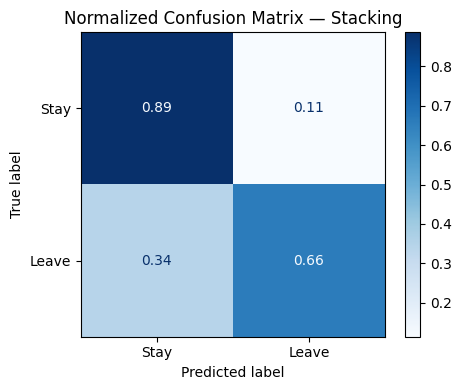

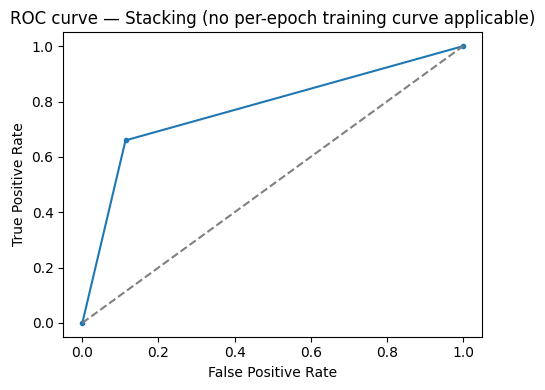

In [18]:
# ============================================================
# 10. DIAGNOSTICS: normalized confusion matrix + loss/accuracy vs epoch
# ============================================================
best_res = all_results[BEST_MODEL_NAME]

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, best_res["y_pred"], normalize="true")
ConfusionMatrixDisplay(cm, display_labels=["Stay", "Leave"]).plot(ax=ax, cmap="Blues", values_format=".2f")
ax.set_title(f"Normalized Confusion Matrix — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.show()

# Loss/accuracy vs epoch — only meaningful for the fine-tuned transformer models,
# which log training loss per epoch via the Trainer's log history.
trainer_lookup = {"DistilBERT": distilbert_trainer, "BERT": bert_trainer}

if BEST_MODEL_NAME in trainer_lookup:
    log_hist = trainer_lookup[BEST_MODEL_NAME].state.log_history
    losses = [(e["epoch"], e["loss"]) for e in log_hist if "loss" in e]
    if losses:
        epochs, loss_vals = zip(*losses)
        plt.figure(figsize=(5, 4))
        plt.plot(epochs, loss_vals, marker="o")
        plt.xlabel("Epoch"); plt.ylabel("Training loss")
        plt.title(f"Training loss vs epoch — {BEST_MODEL_NAME}")
        plt.tight_layout(); plt.show()
else:
    # For classical models / prompted LLMs there is no per-epoch training curve;
    # show the ROC curve instead as the diagnostic in its place.
    fpr, tpr, _ = roc_curve(y_test, all_results[BEST_MODEL_NAME]["y_pred"])
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, marker=".")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC curve — {BEST_MODEL_NAME} (no per-epoch training curve applicable)")
    plt.tight_layout(); plt.show()


## 11. Data augmentation comparison
**(a) SMOTE family** — compared on a representative classical model via cross-validated F1 on the
training set. **(b) Text augmentation** — a lightweight, dependency-free Easy-Data-Augmentation
(random deletion / random swap) is compared against no augmentation for a quickly-trained (1-epoch)
DistilBERT, since a full re-run of every augmentation variant at 3 epochs would be very slow on
free-tier Colab.

SMOTE                mean CV F1 = 0.4086
BorderlineSMOTE      mean CV F1 = 0.4560
ADASYN               mean CV F1 = 0.4358
SMOTETomek           mean CV F1 = 0.4086
RandomOverSampler    mean CV F1 = 0.3287


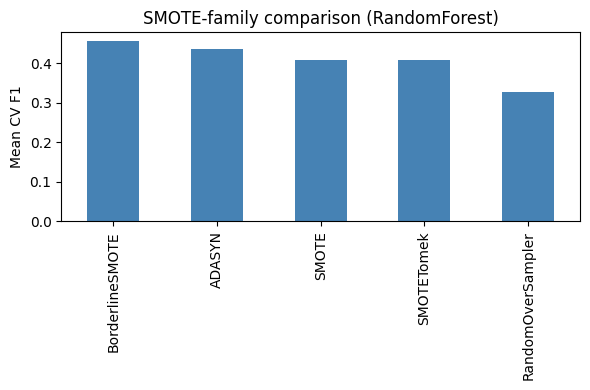

In [19]:
# ============================================================
# 11a. SMOTE-FAMILY COMPARISON (classical branch)
# ============================================================
samplers = {
    "SMOTE": SMOTE(random_state=RANDOM_STATE),
    "BorderlineSMOTE": BorderlineSMOTE(random_state=RANDOM_STATE),
    "ADASYN": ADASYN(random_state=RANDOM_STATE),
    "SMOTETomek": SMOTETomek(random_state=RANDOM_STATE),
    "RandomOverSampler": RandomOverSampler(random_state=RANDOM_STATE),
}

REP_MODEL_NAME = "RandomForest"  # representative classical model for this comparison
sampler_results = {}
for samp_name, sampler in samplers.items():
    pipe = make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), sampler=sampler)
    scores = []
    for tr_idx, va_idx in cv.split(X_train, y_train):
        pipe.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        pred = pipe.predict(X_train.iloc[va_idx])
        scores.append(f1_score(y_train.iloc[va_idx], pred))
    sampler_results[samp_name] = np.mean(scores)
    print(f"{samp_name:20s} mean CV F1 = {np.mean(scores):.4f}")

pd.Series(sampler_results).sort_values(ascending=False).plot(kind="bar", figsize=(6, 4), color="steelblue")
plt.ylabel("Mean CV F1"); plt.title(f"SMOTE-family comparison ({REP_MODEL_NAME})")
plt.tight_layout(); plt.show()


In [20]:
# ============================================================
# 11b. TEXT AUGMENTATION COMPARISON (NLP branch)
# ============================================================
def eda_random_deletion(text, p=0.1):
    words = text.split()
    if len(words) <= 3:
        return text
    kept = [w for w in words if random.random() > p]
    return " ".join(kept) if kept else text

def eda_random_swap(text, n_swaps=1):
    words = text.split()
    for _ in range(n_swaps):
        if len(words) < 2:
            break
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return " ".join(words)

def augment_text(text):
    return eda_random_swap(eda_random_deletion(text))

# Augment only the minority class (label 1) portion of the (already row-balanced) training text
augmented_text_train = text_train + [augment_text(t) for t, l in zip(text_train, label_train) if l == 1]
augmented_label_train = label_train + [l for l in label_train if l == 1]

def quick_finetune_eval(train_texts, train_labels, epochs=1):
    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
    model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)
    train_ds = build_dataset(train_texts, train_labels, tokenizer)
    args = TrainingArguments(
        output_dir="./out_aug_compare", num_train_epochs=epochs,
        per_device_train_batch_size=16, per_device_eval_batch_size=32,
        logging_strategy="epoch", save_strategy="no", report_to=[], seed=RANDOM_STATE,
    )
    trainer = Trainer(model=model, args=args, train_dataset=train_ds, compute_metrics=compute_metrics)
    trainer.train()
    val_proba = transformer_predict_proba(trainer, tokenizer, text_val)
    thr, f1 = find_best_threshold(y_val, val_proba)
    return f1

f1_no_aug = quick_finetune_eval(text_train, label_train, epochs=1)
f1_with_aug = quick_finetune_eval(augmented_text_train, augmented_label_train, epochs=1)

print(f"DistilBERT (1 epoch) val F1 — no text augmentation:   {f1_no_aug:.4f}")
print(f"DistilBERT (1 epoch) val F1 — with text augmentation: {f1_with_aug:.4f}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
93,0.665553


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
139,0.512953


DistilBERT (1 epoch) val F1 — no text augmentation:   0.3598
DistilBERT (1 epoch) val F1 — with text augmentation: 0.4259


## 12. Explainable AI (SHAP + LIME)
Applied to the overall best model. If the best model is from the classical branch, SHAP
(`TreeExplainer` for tree-based models, `KernelExplainer`/linear otherwise) and LIME
(`LimeTabularExplainer`) are used on the preprocessed features. If the best model is from the
NLP/LLM branch, `LimeTextExplainer` is used directly on the serialized text.

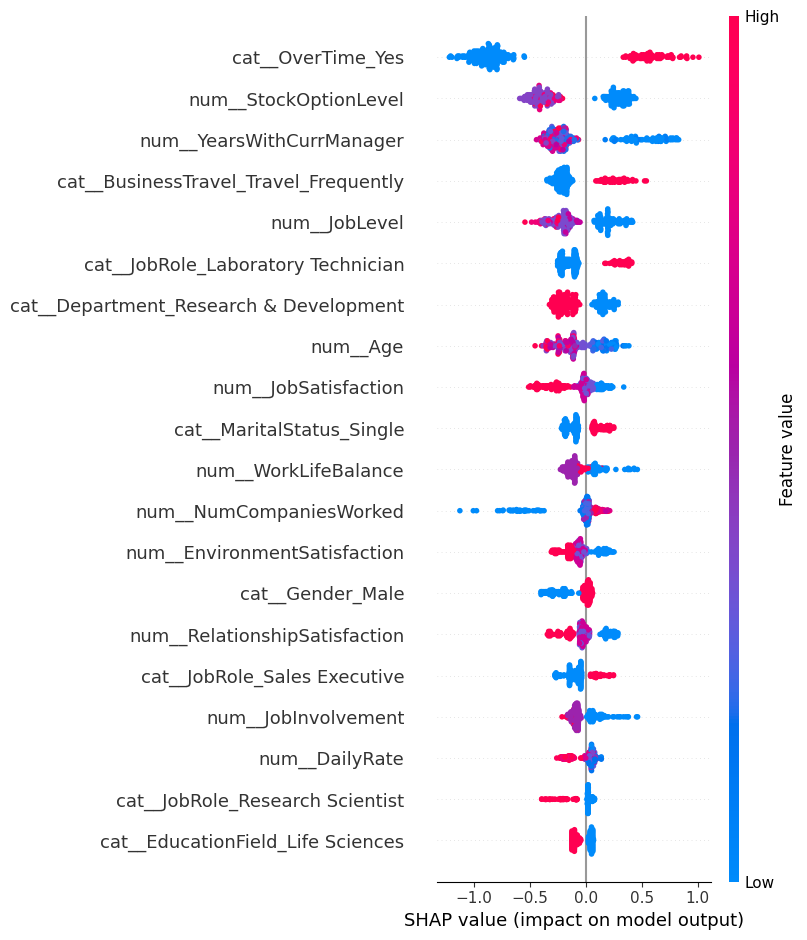

                                 Feature  Importance
0                      cat__OverTime_Yes    0.109324
1                  num__StockOptionLevel    0.031657
2                          num__JobLevel    0.025855
3                   num__JobSatisfaction    0.024966
4          num__RelationshipSatisfaction    0.017361
5                    num__JobInvolvement    0.013288
6  cat__BusinessTravel_Travel_Frequently    0.011365
7           cat__JobRole_Sales Executive    0.009849
8           num__EnvironmentSatisfaction    0.008943
9              num__YearsWithCurrManager    0.008520


In [21]:
from sklearn.inspection import permutation_importance

tree_based_names = ["DecisionTree", "RandomForest", "GradientBoosting"]
best_tree_name = max(tree_based_names, key=lambda n: classical_results[n]["f1"])

best_tree_pipe = tuned_models[best_tree_name]
feature_names = get_feature_names(best_tree_pipe)
X_val_transformed = best_tree_pipe.named_steps["prep"].transform(X_val)
X_test_transformed = best_tree_pipe.named_steps["prep"].transform(X_test)
clf_only = best_tree_pipe.named_steps["clf"]

explainer = shap.TreeExplainer(clf_only)
shap_values = explainer.shap_values(X_test_transformed)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv, X_test_transformed, feature_names=feature_names, show=True)

perm = permutation_importance(clf_only, X_val_transformed, y_val,
                               scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE)
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": perm.importances_mean}
                              ).sort_values("Importance", ascending=False).head(10).reset_index(drop=True)
print(importance_df)

def predict_proba_fn(texts):
    p1 = transformer_predict_proba(distilbert_trainer, distilbert_tok, list(texts))
    return np.column_stack([1 - p1, p1])

lime_text_explainer = LimeTextExplainer(class_names=["Stay", "Leave"])
exp = lime_text_explainer.explain_instance(text_test[0], predict_proba_fn, num_features=10)
exp.show_in_notebook(text=True)

In [22]:
# ============================================================
# 12. EXPLAINABLE AI
# ============================================================
CLASSICAL_NAMES = {"DecisionTree", "SVM", "LogisticRegression", "RandomForest",
                    "GradientBoosting", "Stacking", "Blending"}

if BEST_MODEL_NAME in CLASSICAL_NAMES and BEST_MODEL_NAME in tuned_models:
    best_pipe = tuned_models[BEST_MODEL_NAME]
    feature_names = get_feature_names(best_pipe)
    X_test_transformed = best_pipe.named_steps["prep"].transform(X_test)
    X_train_transformed = best_pipe.named_steps["prep"].transform(X_train)
    clf_only = best_pipe.named_steps["clf"]

    # --- SHAP ---
    if BEST_MODEL_NAME in ("DecisionTree", "RandomForest", "GradientBoosting"):
        explainer = shap.TreeExplainer(clf_only)
        shap_values = explainer.shap_values(X_test_transformed)
        sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    else:
        background = shap.sample(X_train_transformed, 100, random_state=RANDOM_STATE)
        explainer = shap.KernelExplainer(clf_only.predict_proba, background)
        sv = explainer.shap_values(X_test_transformed[:50], nsamples=100)[1]
        X_test_transformed = X_test_transformed[:50]

    shap.summary_plot(sv, X_test_transformed, feature_names=feature_names, show=True)

    # --- LIME (tabular) ---
    lime_explainer = LimeTabularExplainer(
        X_train_transformed, feature_names=list(feature_names),
        class_names=["Stay", "Leave"], discretize_continuous=True, random_state=RANDOM_STATE,
    )
    exp = lime_explainer.explain_instance(X_test_transformed[0], clf_only.predict_proba, num_features=10)
    exp.show_in_notebook(show_table=True)

else:
    # NLP/LLM best model -> LIME text explainer
    lookup = {
        "DistilBERT": (distilbert_trainer, distilbert_tok),
        "BERT": (bert_trainer, bert_tok),
    }
    if BEST_MODEL_NAME in lookup:
        trainer_, tok_ = lookup[BEST_MODEL_NAME]

        def predict_proba_fn(texts):
            p1 = transformer_predict_proba(trainer_, tok_, list(texts))
            return np.column_stack([1 - p1, p1])

        lime_text_explainer = LimeTextExplainer(class_names=["Stay", "Leave"])
        exp = lime_text_explainer.explain_instance(text_test[0], predict_proba_fn, num_features=10)
        exp.show_in_notebook(text=True)
    else:
        print(f"LIME/SHAP demo not wired up for prompted-LLM model '{BEST_MODEL_NAME}'; "
              f"see the DistilBERT/BERT branch above for the pattern to reuse with a custom "
              f"predict_proba wrapper around flan_t5_proba / tinyllama_proba.")


LIME/SHAP demo not wired up for prompted-LLM model 'Stacking'; see the DistilBERT/BERT branch above for the pattern to reuse with a custom predict_proba wrapper around flan_t5_proba / tinyllama_proba.


## 13. Ablation study (retrain-based, on the best model)
Retrains variants of the winning configuration with individual components removed, and reports
the resulting drop in locked-threshold test F1.

Full (best config)    0.584906
Without ensembling    0.512000
Without tuning        0.479167
Without SMOTE         0.446154
dtype: float64


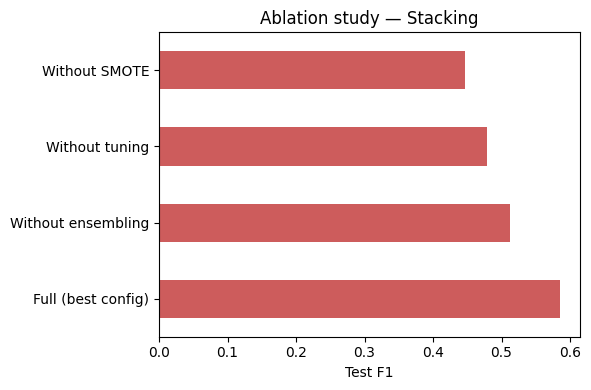

In [23]:
# ============================================================
# 13. ABLATION STUDY
# ============================================================
ablation_results = {"Full (best config)": all_results[BEST_MODEL_NAME]["f1"]}

if BEST_MODEL_NAME in CLASSICAL_NAMES:
    base_name = BEST_MODEL_NAME if BEST_MODEL_NAME in base_models else "RandomForest"
    base_model_cls = base_models[base_name].__class__

    # (a) without SMOTE / class-imbalance handling
    pipe_no_smote = make_pipeline(base_model_cls(random_state=RANDOM_STATE), sampler=None)
    pipe_no_smote.fit(X_train, y_train)
    val_p = pipe_no_smote.predict_proba(X_val)[:, 1]; test_p = pipe_no_smote.predict_proba(X_test)[:, 1]
    thr, _ = find_best_threshold(y_val, val_p)
    ablation_results["Without SMOTE"] = evaluate_locked_threshold(y_test, test_p, thr)["f1"]

    # (b) without hyperparameter tuning (default params, still with SMOTE)
    pipe_no_tune = make_pipeline(base_model_cls(random_state=RANDOM_STATE), sampler=SMOTE(random_state=RANDOM_STATE))
    pipe_no_tune.fit(X_train, y_train)
    val_p = pipe_no_tune.predict_proba(X_val)[:, 1]; test_p = pipe_no_tune.predict_proba(X_test)[:, 1]
    thr, _ = find_best_threshold(y_val, val_p)
    ablation_results["Without tuning"] = evaluate_locked_threshold(y_test, test_p, thr)["f1"]

    # (c) without stacking/blending ensembling (falls back to the single tuned base model)
    if BEST_MODEL_NAME in ("Stacking", "Blending"):
        single_pipe = tuned_models[base_name]
        val_p = single_pipe.predict_proba(X_val)[:, 1]; test_p = single_pipe.predict_proba(X_test)[:, 1]
        thr, _ = find_best_threshold(y_val, val_p)
        ablation_results["Without ensembling"] = evaluate_locked_threshold(y_test, test_p, thr)["f1"]

else:
    # NLP/LLM branch ablations
    if BEST_MODEL_NAME in ("DistilBERT", "BERT"):
        model_name = "distilbert-base-uncased" if BEST_MODEL_NAME == "DistilBERT" else "bert-base-uncased"

        # (a) without class-imbalance handling (train on the original, unbalanced text set)
        trainer_nb, tok_nb = finetune_transformer(model_name, epochs=3)
        # re-finetune manually on non-oversampled data:
        tok_raw = AutoTokenizer.from_pretrained(model_name)
        model_raw = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
        raw_text_train = X_train.apply(serialize_row, axis=1).tolist()
        raw_label_train = y_train.tolist()
        train_ds_raw = build_dataset(raw_text_train, raw_label_train, tok_raw)
        args_raw = TrainingArguments(output_dir="./out_ablation_nobalance", num_train_epochs=3,
                                      per_device_train_batch_size=16, logging_strategy="epoch",
                                      save_strategy="no", report_to=[], seed=RANDOM_STATE)
        trainer_raw = Trainer(model=model_raw, args=args_raw, train_dataset=train_ds_raw,
                               compute_metrics=compute_metrics)
        trainer_raw.train()
        val_p = transformer_predict_proba(trainer_raw, tok_raw, text_val)
        test_p = transformer_predict_proba(trainer_raw, tok_raw, text_test)
        thr, _ = find_best_threshold(y_val, val_p)
        ablation_results["Without class-imbalance handling"] = evaluate_locked_threshold(y_test, test_p, thr)["f1"]

        # (b) fewer epochs (1 instead of 3) as a "less training" ablation
        f1_1ep = quick_finetune_eval(text_train, label_train, epochs=1)
        ablation_results["Only 1 epoch (vs 3)"] = f1_1ep
    else:
        print(f"No retrain-based ablation wired up for prompted-LLM model '{BEST_MODEL_NAME}' "
              f"(no training/fine-tuning occurs for it, so 'retraining' does not apply the same way).")

ablation_df = pd.Series(ablation_results).sort_values(ascending=False)
print(ablation_df)
ablation_df.plot(kind="barh", figsize=(6, 4), color="indianred")
plt.xlabel("Test F1"); plt.title(f"Ablation study — {BEST_MODEL_NAME}")
plt.tight_layout(); plt.show()


## 14. Final summary

In [24]:
# ============================================================
# 14. FINAL LEADERBOARD
# ============================================================
print("="*70)
print("FINAL LEADERBOARD (locked-threshold TEST metrics)")
print("="*70)
print(leaderboard[["threshold", "accuracy", "precision", "recall", "f1", "roc_auc"]].round(4))
print("\nOverall best model:", BEST_MODEL_NAME)


FINAL LEADERBOARD (locked-threshold TEST metrics)
                    threshold  accuracy  precision  recall      f1  roc_auc
Stacking                 0.33    0.8503     0.5254  0.6596  0.5849   0.7989
LogisticRegression       0.68    0.8367     0.4923  0.6809  0.5714   0.7982
DistilBERT               0.67    0.8265     0.4697  0.6596  0.5487   0.7758
SVM                      0.57    0.8027     0.4304  0.7234  0.5397   0.7849
Blending                 0.41    0.8605     0.5750  0.4894  0.5287   0.8021
GradientBoosting         0.38    0.8197     0.4516  0.5957  0.5138   0.7840
RandomForest             0.33    0.7925     0.4103  0.6809  0.5120   0.7813
BERT                     0.59    0.7857     0.4000  0.6809  0.5039   0.7823
DecisionTree             0.54    0.8163     0.4386  0.5319  0.4808   0.7370
TinyLlama                0.05    0.3537     0.1794  0.8511  0.2963   0.5714
Flan-T5                  0.12    0.3639     0.1729  0.7872  0.2835   0.5881

Overall best model: Stacking
